# Emilio Leon
## Kmeans
### 25/03/2026

In [2]:
import numpy as np
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.cluster import KMeans
import os
os.environ["OMP_NUM_THREADS"] = '1'
import matplotlib.pyplot as plt

In [3]:
iris = load_iris()
datos = iris.data

In [4]:
X = pd.DataFrame(datos, columns=["sepal_length", "sepal_width", "petal_length", "petal_width"])
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
inertias = []

In [6]:
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

C:\Users\ealeo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ealeo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ealeo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ealeo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

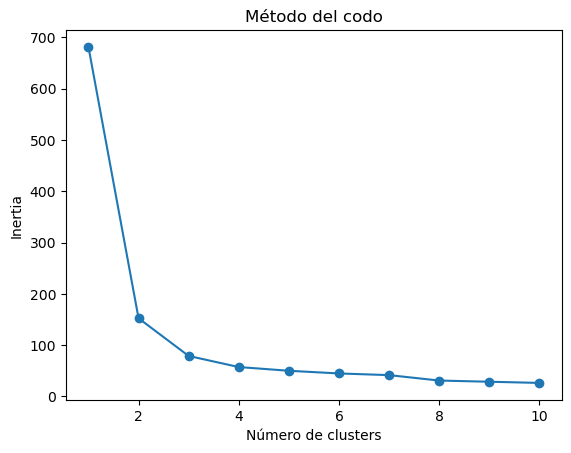

In [7]:
plt.plot(range(1,11), inertias, marker='o')
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inertia")
plt.show()

### El codo está entre dos y tres, pero parece que 3 podría ser un poco mejor.

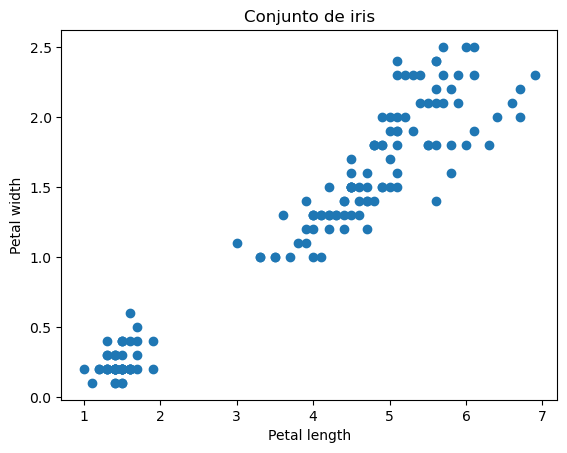

In [8]:
plt.scatter(X["petal_length"], X["petal_width"])
plt.title("Conjunto de iris")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.show()

In [9]:
kmeans = KMeans(n_clusters=3, n_init='auto')
kmeans.fit(X)

C:\Users\ealeo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3)

In [10]:
kmeans.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2], dtype=int32)

In [11]:
# Ubicación de los centros
kmeans.cluster_centers_

array([[5.006     , 3.428     , 1.462     , 0.246     ],
       [6.85384615, 3.07692308, 5.71538462, 2.05384615],
       [5.88360656, 2.74098361, 4.38852459, 1.43442623]])

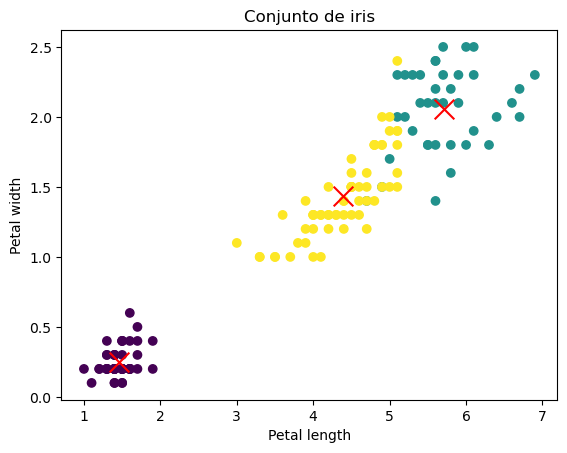

In [19]:
plt.scatter(X["petal_length"], X["petal_width"], c = kmeans.labels_)
plt.scatter(kmeans.cluster_centers_[:,2], kmeans.cluster_centers_[:,3], c = "red", marker = "x", s = 200, label = "Centroides")
plt.title("Conjunto de iris")
plt.title("Conjunto de iris")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.show()

### La distribución se ve bastante buena

In [13]:
diccionario_predict = {"sepal_length": [6.5], "sepal_width": [3.0], "petal_length": [5.2], "petal_width": [2.0]}

In [14]:
df_predict = pd.DataFrame(diccionario_predict)
df_predict

,sepal_length,sepal_width,petal_length,petal_width
0,6.5,3.0,5.2,2.0


In [15]:
kmeans.predict(df_predict)

array([1], dtype=int32)

In [16]:
kmeans.inertia_

78.8556658259773

In [17]:
from sklearn.metrics import silhouette_score
silhouette = silhouette_score(X, kmeans.labels_)

In [18]:
silhouette

np.float64(0.5511916046195919)

### Ambas métricas muestrasn una robustez del módelo media, pues la silhouette es positiva, pero menor a .6, y la inercia es un poco alta.